# Libraries

In [35]:
# !pip install ipympl
%matplotlib widget

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn import svm
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer

# PLOTTING FUNCTIONS

In [37]:
def elbow_plot(k_values, acc_scores, model):
    
    plt.plot(k_values, acc_scores, marker='o')
    plt.xlabel('Number of Folds')
    plt.ylabel('Accuracy-score')
    plt.title(f'Elbow Plot - F1-score - {model}')
    plt.show()
    output_file = f'/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/accuracy_over_folds_graphs/elbowplot_{model}_f1.png'
    # output_file = f'/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/accuracy_over_folds_graphs/elbowplot_{model}_f1.png'
    plt.savefig(output_file, bbox_inches='tight')
    plt.close()

In [38]:
def cm_plot(cm_scores, acc_scores, model, total=False):
    if total:
        # Compute the total confusion matrix
        cm_value = np.sum(cm_scores, axis=0)
        title = f'Confusion Matrix - Total F1-score - {model}'
    else:
        # Retrieve the confusion matrix with the highest F1-score
        cm_value = cm_scores[np.argmax(acc_scores)]
        title = f'Confusion Matrix - Highest F1-score - {model}'

    classes = ['Low mental workload', 'High mental workload']


    plt.figure(figsize=(8, 6))
    plt.imshow(cm_value, interpolation='nearest', cmap='coolwarm')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Add the values to the confusion matrix plot
    thresh = cm_value.max() / 2.0
    for i in range(cm_value.shape[0]):
        for j in range(cm_value.shape[1]):
            plt.text(j, i, format(cm_value[i, j], 'd'), ha='center', va='center',
                     color='white' if cm_value[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.show()
    output_file = f'/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/confusion_matrices/cmplot_{model}.png'
    # output_file = f'/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/confusion_matrices/cmplot_{model}.png'
    plt.savefig(output_file, bbox_inches='tight')
    plt.close()

In [39]:
def cirkel_diagram(channel_counts, model):

    channel_groups = {
        'P': [channel for channel in channel_counts.keys() if channel.startswith('P')],
        'F': [channel for channel in channel_counts.keys() if channel.startswith('F')],
        'C': [channel for channel in channel_counts.keys() if channel.startswith('C')],
        'O': [channel for channel in channel_counts.keys() if channel.startswith('O')],
        'T': [channel for channel in channel_counts.keys() if channel.startswith('T')]
    }

    group_counts = {group: 0 for group in channel_groups}
    for channel, count in channel_counts.items():
        for group, channels in channel_groups.items():
            if channel in channels:
                group_counts[group] += count

    labels = group_counts.keys()
    sizes = group_counts.values()
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
    explode = [0.1] * len(group_counts)  # explode all the slices

    plt.pie(sizes, labels=labels, colors=colors, explode=explode, autopct='%1.1f%%', startangle=90)

    plt.axis('equal')
    plt.title(f'Brain Region Distribution of chosen spectral features - {model}')
    plt.show()
    output_file = f'/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/brain_area_distribution_selected_spectral_features/cirkeldiagram_{model}.png'
    # output_file = f'/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/brain_area_distribution_selected_spectral_features/cirkeldiagram_{model}.png'
    plt.savefig(output_file, bbox_inches='tight')
    plt.close()

In [40]:
def barplot_features(channel_counts, frequency_bands, all_channels, model):

    unique_channels = list(channel_counts.keys())
    custom_order = ['F', 'O', 'T', 'C', 'P']
    unique_channels = sorted(unique_channels, key=lambda x: (custom_order.index(x[0]), x))
    colors = ['r', 'g', 'b']
    x = np.arange(len(all_channels))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    bottom = np.zeros(len(all_channels))

    for i, freq in zip(range(len(frequency_bands)), ['Alpha', 'Beta', 'Theta']):
        values = [channel_counts[channel] if channel in frequency_bands[i] else 0 for channel in all_channels]
        ax.bar(x, values, bottom=bottom, label=f"{freq}", color=colors[i])
        bottom += values
    
    ax.set_xlabel('Channels chosen accross frequency ranges', fontsize=10)
    ax.set_title(f'Chosen spectral features by {model}', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(all_channels, rotation=45, ha='right', fontsize=8)
    ax.yaxis.set_ticks([])
    ax.legend()
    plt.show()
    output_file = f'/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/barplot_for_selected_spectral_features/barplotspectralfeatures_{model}.png'
    # output_file = f'/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/barplot_for_selected_spectral_features/barplotspectralfeatures_{model}.png'
    plt.savefig(output_file, bbox_inches='tight')
    plt.close()

In [41]:
def barplot_PLVfeatures(channel_counts, frequency_bands, all_channels, model):
    
    unique_channels = list(channel_counts.keys())
    
    if len(unique_channels) > 1:
        custom_order = ['a', 'b', 't']
        unique_channels = sorted(unique_channels, key=lambda x: (custom_order.index(x[0]), x))

    colors = ['r', 'g', 'b']
    x = np.arange(len(all_channels))

    fig, ax = plt.subplots(figsize=(8, 6))
    bottom = np.zeros(len(all_channels))

    for i, freq in zip(range(len(frequency_bands)), ['Alpha', 'Beta', 'Theta']):
        values = [channel_counts[channel] if channel in frequency_bands[i] else 0 for channel in all_channels]
        ax.bar(x, values, bottom=bottom, label=f"{freq}", color=colors[i])
        bottom += values

    ax.set_position([0.1, 0.1, 0.9, 0.3])
    ax.set_xlabel('PLV per channel and frequency band', fontsize=10)
    ax.set_title(f'Chosen PLV features by {model}', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(all_channels, rotation=45, ha='right', fontsize=8)
    ax.yaxis.set_ticks([])
    plt.show()
    output_file = f'/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/barplots_for_selected_PLV_features/barplotPLVfeatures_{model}.png'
    # output_file = f'/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/barplots_for_selected_PLV_features/barplotPLVfeatures_{model}.png'
    plt.savefig(output_file, bbox_inches='tight')
    plt.close()

# Frontal-Parietal PLV value calculation

In [42]:
def frontal_parietal_PLVs(data):
    '''
    Calculates the connectivity between the frontal and parietal areas in the brain.
    
    Parameters:
        data (array-like): Connectivity data between each channel.
    
    Computation: 
        - mean connectivity for each channel based on it's connectivity values with all opposite brain region channels.
        - mean connectivity for each brain region
        - mean connectivity between frontal and parietal brain regions.
    
    Returns:
        numpy.ndarray: Frontal-parietal connectivity values for each frequency band (alpha, beta, theta) and for each channel and it's connectivity with the other side.
    '''
        
    # Alpha PLV mean values
    F7 = np.mean(data[4:9])
    F3 = np.mean(data[12:17])
    Fz = np.mean(data[19:24])
    F4 = np.mean(data[25:30])
    F8 = np.mean(data[30:35])
    P3 = np.mean(np.concatenate((data[4:5], data[12:13], data[19:20], data[25:26], data[30:31])))
    Pz = np.mean(np.concatenate((data[5:6], data[13:14], data[20:21], data[26:27], data[31:32])))
    P4 = np.mean(np.concatenate((data[6:7], data[14:15], data[21:22], data[27:28], data[32:33])))
    PO7 = np.mean(np.concatenate((data[7:8], data[15:16], data[22:23], data[28:29], data[33:34])))
    PO8 = np.mean(np.concatenate((data[8:9], data[16:17], data[23:24], data[29:30], data[34:35])))
    PLVs_alpha = np.concatenate(([F7], [F3], [Fz], [F4], [F8], [P3], [Pz], [P4], [PO7], [PO8]))

    # Beta PLV mean values
    F7 = np.mean(data[4+45:9+45])
    F3 = np.mean(data[12+45:17+45])
    Fz = np.mean(data[19+45:24+45])
    F4 = np.mean(data[25+45:30+45])
    F8 = np.mean(data[30+45:35+45])
    P3 = np.mean(np.concatenate((data[4+45:5+45], data[12+45:13+45], data[19+45:20+45], data[25+45:26+45], data[30+45:31+45])))
    Pz = np.mean(np.concatenate((data[5+45:6+45], data[13+45:14+45], data[20+45:21+45], data[26+45:27+45], data[31+45:32+45])))
    P4 = np.mean(np.concatenate((data[6+45:7+45], data[14+45:15+45], data[21+45:22+45], data[27+45:28+45], data[32+45:33+45])))
    PO7 = np.mean(np.concatenate((data[7+45:8+45], data[15+45:16+45], data[22+45:23+45], data[28+45:29+45], data[33+45:34+45])))
    PO8 = np.mean(np.concatenate((data[8+45:9+45], data[16+45:17+45], data[23+45:24+45], data[29+45:30+45], data[34+45:35+45])))
    PLVs_beta = np.concatenate(([F7], [F3], [Fz], [F4], [F8], [P3], [Pz], [P4], [PO7], [PO8]))

    # Theta PLV mean values
    F7 = np.mean(data[4+90:9+90])
    F3 = np.mean(data[12+90:17+90])
    Fz = np.mean(data[19+90:24+90])
    F4 = np.mean(data[25+90:30+90])
    F8 = np.mean(data[30+90:35+90])
    P3 = np.mean(np.concatenate((data[4+90:5+90], data[12+90:13+90], data[19+90:20+90], data[25+90:26+90], data[30+90:31+90])))
    Pz = np.mean(np.concatenate((data[5+90:6+90], data[13+90:14+90], data[20+90:21+90], data[26+90:27+90], data[31+90:32+90])))
    P4 = np.mean(np.concatenate((data[6+90:7+90], data[14+90:15+90], data[21+90:22+90], data[27+90:28+90], data[32+90:33+90])))
    PO7 = np.mean(np.concatenate((data[7+90:8+90], data[15+90:16+90], data[22+90:23+90], data[28+90:29+90], data[33+90:34+90])))
    PO8 = np.mean(np.concatenate((data[8+90:9+90], data[16+90:17+90], data[23+90:24+90], data[29+90:30+90], data[34+90:35+90])))
    PLVs_theta = np.concatenate(([F7], [F3], [Fz], [F4], [F8], [P3], [Pz], [P4], [PO7], [PO8]))
    
    data_x = np.concatenate((PLVs_alpha, PLVs_beta, PLVs_theta))
    
    return data_x


# Baseline Model - RFE on 42 spectral features and SVM

In [43]:
# loading data 

directory = '/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/data'
# directory = '/Flight-Sim-Cognitive-Workload-EEG-Prediction/data'

concatenated_X, concatenated_Y = [], []

for subdir in sorted(os.listdir(directory))[1:]: # index from 1 because Mac has .DS_Store file
    for file in sorted(os.listdir(os.path.join(directory, subdir))):
        data = np.load(os.path.join(directory, subdir, file))
        X = data['X'][135:] # extract all spectral features
        Y = data['Y']
        concatenated_X.append(X)
        concatenated_Y.append(Y)

concatenated_Y = np.concatenate(concatenated_Y)
    

Fold 1 - Accuracy-score: 0.17 - Best Parameters: {'C': 0.95, 'gamma': 0.0001, 'kernel': 'linear'}
Fold 2 - Accuracy-score: 0.2 - Best Parameters: {'C': 0.1, 'gamma': 10, 'kernel': 'poly'}
Fold 3 - Accuracy-score: 0.2 - Best Parameters: {'C': 0.1, 'gamma': 10, 'kernel': 'poly'}
Fold 4 - Accuracy-score: 0.6 - Best Parameters: {'C': 10, 'gamma': 0.0001, 'kernel': 'linear'}
Fold 5 - Accuracy-score: 0.2 - Best Parameters: {'C': 10, 'gamma': 0.0001, 'kernel': 'linear'}
Fold 6 - Accuracy-score: 0.4 - Best Parameters: {'C': 10, 'gamma': 0.95, 'kernel': 'rbf'}
Fold 7 - Accuracy-score: 0.6 - Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'poly'}
Fold 8 - Accuracy-score: 0.4 - Best Parameters: {'C': 10, 'gamma': 0.0001, 'kernel': 'linear'}
Fold 9 - Accuracy-score: 0.4 - Best Parameters: {'C': 10, 'gamma': 25, 'kernel': 'rbf'}
Fold 10 - Accuracy-score: 0.2 - Best Parameters: {'C': 0.95, 'gamma': 0.95, 'kernel': 'poly'}
 
Mean Accuracy-score: 0.34. Std Accuracy-score: 0.16. Max Accuracy-score: 0

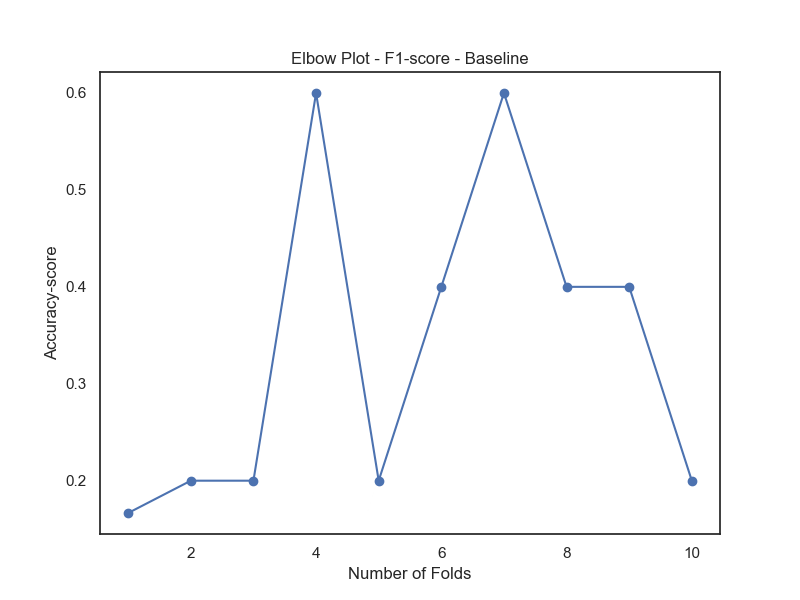

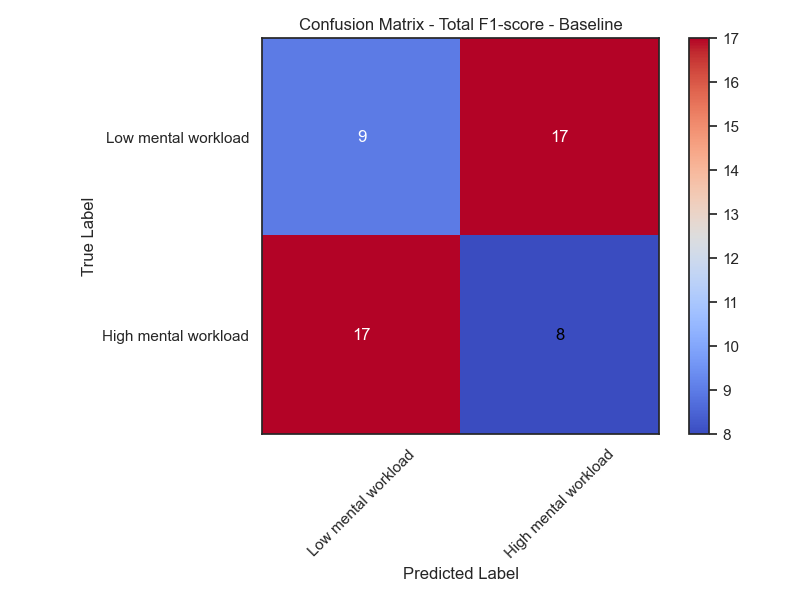

In [44]:
# SVM + RFE

X = concatenated_X
Y = concatenated_Y
classifier = svm.SVC(random_state=42)
parameters = {'C': [0.1, 0.95, 0.99, 10], 'kernel': ['linear', 'rbf', 'sigmoid', 'poly'], 'gamma': [0.0001, 0.01, 0.95, 1, 10, 25]}
scoring = make_scorer(accuracy_score)
num_folds = 10
num_features = 8
kf = KFold(n_splits=num_folds, shuffle=False)

f1_scores, accuracy_scores, precision_scores, recall_scores, cm_scores, best_parameters_list = [],[],[],[],[],[]
k_values = list(range(1, num_folds + 1))

for k, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train, X_test = np.array(X)[train_index], np.array(X)[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]
    
    # Perform feature selection using RFE with LinearSVC as the estimator
    estimator = svm.LinearSVC(max_iter=1000000)
    selector = RFE(estimator, n_features_to_select=num_features)
    selector.fit(X_train, Y_train)
    X_train_selected = selector.transform(X_train)
    X_test_selected = selector.transform(X_test)
    
    selected_feature_indices = selector.support_
    selected_feature_ranking = selector.ranking_

    grid_search = GridSearchCV(classifier, parameters, scoring=scoring)
    grid_search.fit(X_train_selected, Y_train)

    best_parameters = grid_search.best_params_

    classifier = svm.SVC(kernel=best_parameters['kernel'], C=best_parameters['C'], gamma=best_parameters['gamma'])
    classifier.fit(X_train_selected, Y_train)

    Y_pred = classifier.predict(X_test_selected)

    best_parameters_list.append(best_parameters) 
    f1_scores.append(f1_score(Y_test, Y_pred, zero_division=1))
    accuracy_scores.append(accuracy_score(Y_test, Y_pred))
    precision_scores.append(precision_score(Y_test, Y_pred, zero_division=1))
    recall_scores.append(recall_score(Y_test, Y_pred, zero_division=1))
    cm_scores.append(confusion_matrix(Y_test, Y_pred))
    
    acc = accuracy_score(Y_test, Y_pred)
    print(f'Fold {k} - Accuracy-score: {round(acc, 2)} - Best Parameters: {best_parameters}')

baseline_model_acc = accuracy_scores
baseline_model_param = best_parameters_list[np.argmax(accuracy_scores)]

print(' ')
print('Mean Accuracy-score:', f'{round(np.mean(accuracy_scores), 2)}.', 'Std Accuracy-score:', f'{round(np.std(accuracy_scores), 2)}.', 'Max Accuracy-score:', round(np.max(accuracy_scores), 2), '\n', f'with Hyperparameter set: {best_parameters_list[np.argmax(accuracy_scores)]}')
print(' ')
print('Mean F1-score:', f'{round(np.mean(f1_scores), 2)}.', 'Std F1-score:', f'{round(np.std(f1_scores), 2)}.','Max F1-score:', round(np.max(f1_scores), 2), '\n', f'with Hyperparameter set: {best_parameters_list[np.argmax(f1_scores)]}')
print(' ')
print('Mean Precision-score:', f'{round(np.mean(precision_scores), 2)}.', 'Std Precision-score:', f'{round(np.std(precision_scores), 2)}.', 'Max Precision-score:', round(np.max(precision_scores), 2), '\n', f'with Hyperparameter set: {best_parameters_list[np.argmax(precision_scores)]}')
print(' ')
print('Mean Recall-score:', f'{round(np.mean(recall_scores), 2)}.', 'Std Recall-score:', f'{round(np.std(recall_scores), 2)}.', 'Max Recall-score:', round(np.max(recall_scores), 2), '\n', f'with Hyperparameter set: {best_parameters_list[np.argmax(recall_scores)]}')
print(' ')

elbow_plot(k_values, accuracy_scores, model='Baseline')
cm_plot(cm_scores, accuracy_scores, model='Baseline', total=True)

No such comm: da5f1648423d40acb3e0f0df38efa2f5
No such comm: 46d4f92eb4354309a85acb4336700fc1


Number of chosen spectral features per frequency band: , 
Alpha: 3 
Beta: 3 
Theta: 2
Spectral features per frequency band: 
Alpha: ['F4', 'Cz', 'PO8'] 
Beta: ['T7', 'T8', 'PO8'] 
Theta: ['F3', 'T8']


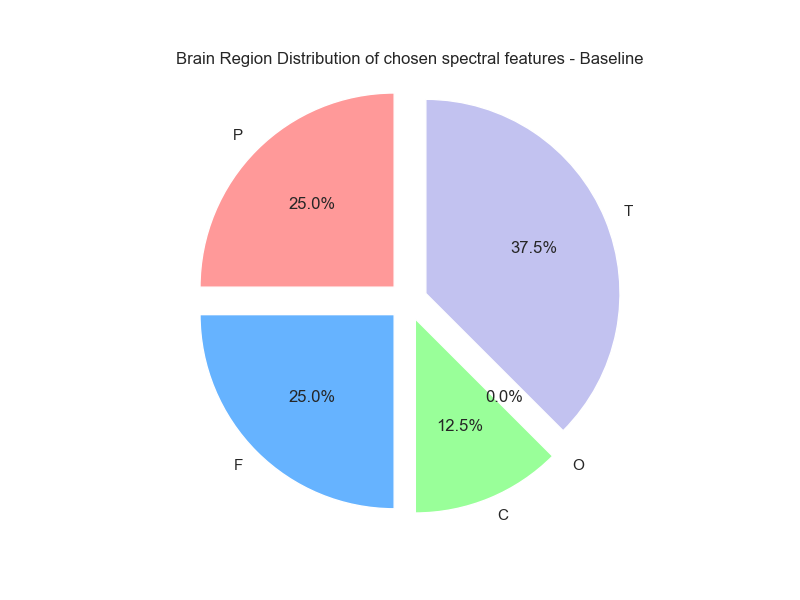

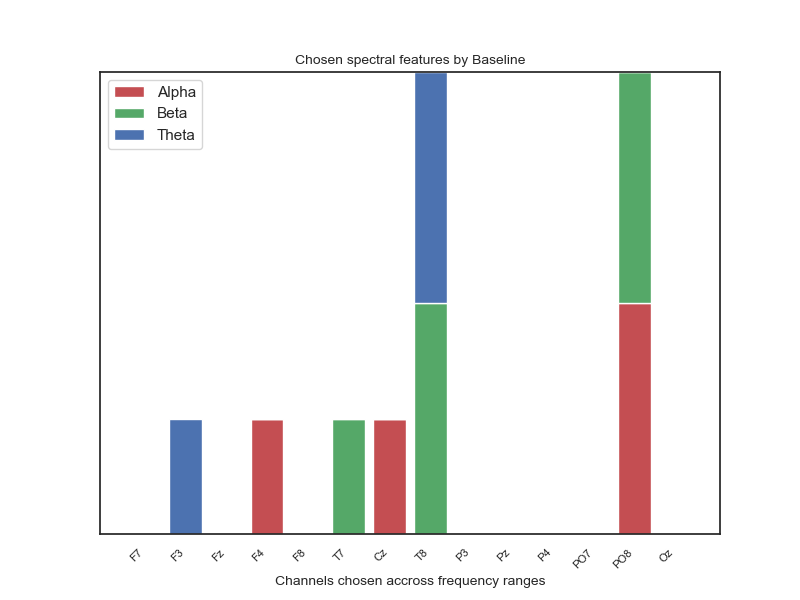

In [45]:
# plot and print features selected by the model

indexes_baseline = np.where(selected_feature_indices)[0]
node_names_orig = ['F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'Cz', 'T8', 'P3', 'Pz', 'P4', 'PO7', 'PO8', 'Oz']
combinations_total = node_names_orig*3

alpha_spec, beta_spec, theta_spec = [], [], []
for i in indexes_baseline:
    if i < 14:
        alpha_spec.append(combinations_total[i])
    elif i >= 14 and i < 28:
        beta_spec.append(combinations_total[i])
    elif i >= 28 and i < 42:
        theta_spec.append(combinations_total[i])
print(f'Number of chosen spectral features per frequency band: , \nAlpha: {len(alpha_spec)} \nBeta: {len(beta_spec)} \nTheta: {len(theta_spec)}')
print(f'Spectral features per frequency band: \nAlpha: {alpha_spec} \nBeta: {beta_spec} \nTheta: {theta_spec}')

frontal_count, parietal_count = 0, 0
channel_counts = {}
frequency_bands = [alpha_spec, beta_spec, theta_spec]
for frequency_band in frequency_bands:
    for channel in frequency_band:
        if channel in channel_counts:
            channel_counts[channel] += 1
        else:
            channel_counts[channel] = 1

cirkel_diagram(channel_counts, model='Baseline')
barplot_features(channel_counts, frequency_bands, node_names_orig, model='Baseline')

chosen_frequency_bands = [alpha_spec, beta_spec, theta_spec]
  

# Model PLV - RFE on 42 spectral features + 30 frontal-parietal PLV features and SVM

In [46]:
# loading data 

directory = '/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/data'
# directory = '/Flight-Sim-Cognitive-Workload-EEG-Prediction/data'

concatenated_X, concatenated_Y = [], []

for subdir in sorted(os.listdir(directory))[1:]: # index from 1 because Mac has .DS_Store file
    for file in sorted(os.listdir(os.path.join(directory, subdir))):
        data = np.load(os.path.join(directory, subdir, file))
        X_PLV = frontal_parietal_PLVs(data['X'][:135]) # 30 PLV features (10 alpha, 10 beta, 10 theta)
        X_Freq = data['X'][135:] # frequency spectrum features
        X = np.concatenate((X_PLV, X_Freq))
        Y = data['Y']
        concatenated_X.append(X)
        concatenated_Y.append(Y)

concatenated_Y = np.concatenate(concatenated_Y)


Fold 1 - Accuracy-score: 0.33 - Best Parameters: {'C': 10, 'gamma': 10, 'kernel': 'rbf'}
Fold 2 - Accuracy-score: 0.4 - Best Parameters: {'C': 0.95, 'gamma': 0.95, 'kernel': 'poly'}
Fold 3 - Accuracy-score: 0.8 - Best Parameters: {'C': 10, 'gamma': 0.95, 'kernel': 'rbf'}
Fold 4 - Accuracy-score: 0.6 - Best Parameters: {'C': 0.99, 'gamma': 10, 'kernel': 'rbf'}
Fold 5 - Accuracy-score: 1.0 - Best Parameters: {'C': 0.95, 'gamma': 10, 'kernel': 'rbf'}
Fold 6 - Accuracy-score: 0.6 - Best Parameters: {'C': 0.95, 'gamma': 10, 'kernel': 'rbf'}
Fold 7 - Accuracy-score: 0.4 - Best Parameters: {'C': 10, 'gamma': 0.95, 'kernel': 'rbf'}
Fold 8 - Accuracy-score: 0.4 - Best Parameters: {'C': 10, 'gamma': 0.0001, 'kernel': 'linear'}
Fold 9 - Accuracy-score: 0.8 - Best Parameters: {'C': 0.95, 'gamma': 10, 'kernel': 'rbf'}
Fold 10 - Accuracy-score: 0.4 - Best Parameters: {'C': 0.95, 'gamma': 10, 'kernel': 'rbf'}
 
Mean Accuracy-score: 0.57. Std Accuracy-score: 0.22. Max Accuracy-score: 1.0 
 with Hyperp

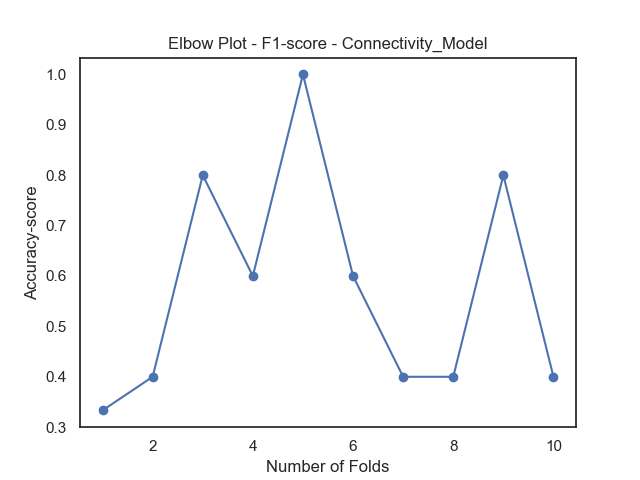

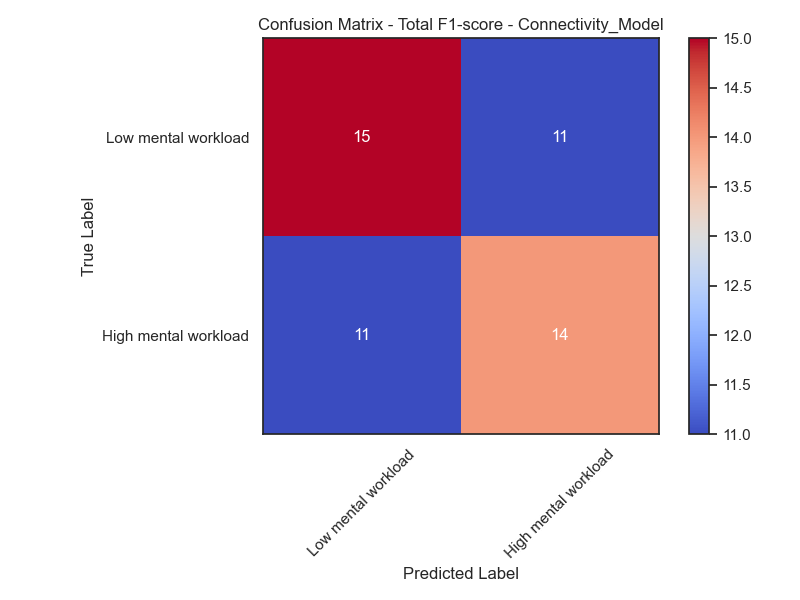

In [47]:
# SVM + RFE

X = concatenated_X
Y = concatenated_Y
classifier = svm.SVC(random_state=42)
parameters = {'C': [0.1, 0.95, 0.99, 10], 'kernel': ['linear', 'rbf', 'sigmoid', 'poly'], 'gamma': [0.0001, 0.01, 0.95, 1, 10, 25]}
scoring = make_scorer(accuracy_score)
num_folds = 10
num_features = 8
kf = KFold(n_splits=num_folds)

f1_scores, accuracy_scores, precision_scores, recall_scores, cm_scores, best_parameters_list = [],[],[],[],[],[]
k_values = list(range(1, num_folds + 1))

for k, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train, X_test = np.array(X)[train_index], np.array(X)[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]
    
    # Perform feature selection using RFE with LinearSVC as the estimator
    estimator = svm.LinearSVC(max_iter=1000000)
    selector = RFE(estimator, n_features_to_select=num_features)
    selector.fit(X_train, Y_train)
    X_train_selected = selector.transform(X_train)
    X_test_selected = selector.transform(X_test)
    
    selected_feature_indices = selector.support_
    selected_feature_ranking = selector.ranking_

    grid_search = GridSearchCV(classifier, parameters, scoring=scoring)
    grid_search.fit(X_train_selected, Y_train)

    best_parameters = grid_search.best_params_

    classifier = svm.SVC(kernel=best_parameters['kernel'], C=best_parameters['C'], gamma=best_parameters['gamma'])
    classifier.fit(X_train_selected, Y_train)

    Y_pred = classifier.predict(X_test_selected)

    best_parameters_list.append(best_parameters) 
    f1_scores.append(f1_score(Y_test, Y_pred, zero_division=1))
    accuracy_scores.append(accuracy_score(Y_test, Y_pred))
    precision_scores.append(precision_score(Y_test, Y_pred, zero_division=1))
    recall_scores.append(recall_score(Y_test, Y_pred, zero_division=1))
    cm_scores.append(confusion_matrix(Y_test, Y_pred))
    
    acc = accuracy_score(Y_test, Y_pred)
    print(f'Fold {k} - Accuracy-score: {round(acc, 2)} - Best Parameters: {best_parameters}')

model_PLV_acc = accuracy_scores
model_PLV_param = best_parameters_list[np.argmax(accuracy_scores)]

print(' ')
print('Mean Accuracy-score:', f'{round(np.mean(accuracy_scores), 2)}.', 'Std Accuracy-score:', f'{round(np.std(accuracy_scores), 2)}.', 'Max Accuracy-score:', round(np.max(accuracy_scores), 2), '\n', f'with Hyperparameter set: {best_parameters_list[np.argmax(accuracy_scores)]}')
print(' ')
print('Mean F1-score:', f'{round(np.mean(f1_scores), 2)}.', 'Std F1-score:', f'{round(np.std(f1_scores), 2)}.','Max F1-score:', round(np.max(f1_scores), 2), '\n', f'with Hyperparameter set: {best_parameters_list[np.argmax(f1_scores)]}')
print(' ')
print('Mean Precision-score:', f'{round(np.mean(precision_scores), 2)}.', 'Std Precision-score:', f'{round(np.std(precision_scores), 2)}.', 'Max Precision-score:', round(np.max(precision_scores), 2), '\n', f'with Hyperparameter set: {best_parameters_list[np.argmax(precision_scores)]}')
print(' ')
print('Mean Recall-score:', f'{round(np.mean(recall_scores), 2)}.', 'Std Recall-score:', f'{round(np.std(recall_scores), 2)}.', 'Max Recall-score:', round(np.max(recall_scores), 2), '\n', f'with Hyperparameter set: {best_parameters_list[np.argmax(recall_scores)]}')
print(' ')

elbow_plot(k_values, accuracy_scores, model='Connectivity_Model')
cm_plot(cm_scores, accuracy_scores, model='Connectivity_Model', total=True)

In [66]:
# print spectral and PLV features selected by the model

indexes = np.where(selected_feature_indices)[0]
plv_names = ['F7', 'F3', 'Fz', 'F4', 'F8', 'P3', 'Pz', 'P4', 'PO7', 'PO8']
node_names_orig = ['F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'Cz', 'T8', 'P3', 'Pz', 'P4', 'PO7', 'PO8', 'Oz']
combinations_total = plv_names*3 + node_names_orig*3

alpha_plv, beta_plv, theta_plv = [], [], []
alpha_spec, beta_spec, theta_spec = [], [], []
for i in indexes:
    if i < 10:
        alpha_plv.append(combinations_total[i])
    elif i >= 10 and i < 20:
        beta_plv.append(combinations_total[i])
    elif i >= 20 and i < 30:
        theta_plv.append(combinations_total[i])
    elif i >= 30 and i < 44:
        alpha_spec.append(combinations_total[i])
    elif i >= 44 and i < 58:
        beta_spec.append(combinations_total[i])
    elif i >= 58 and i < 72:
        theta_spec.append(combinations_total[i])
        
print('Number of PLV features chosen: ', len(alpha_plv), len(beta_plv), len(theta_plv))
print(f'PLV features per frequency band: \nAlpha: {alpha_plv} \nBeta: {beta_plv} \nTheta: {theta_plv}')
print(' ')
print('Number of Spectral features chosen: ', len(alpha_spec), len(beta_spec), len(theta_spec))
print(f'Spectral features per frequency band: \nAlpha: {alpha_spec} \nBeta: {beta_spec} \nTheta: {theta_spec}')
chosen_PLVs = [alpha_plv, beta_plv, theta_plv]

Number of PLV features chosen:  3 1 1
PLV features per frequency band: 
Alpha: ['Fz', 'F4', 'PO7'] 
Beta: ['F4'] 
Theta: ['P4']
 
Number of Spectral features chosen:  2 1 0
Spectral features per frequency band: 
Alpha: ['Cz', 'Pz'] 
Beta: ['T7'] 
Theta: []


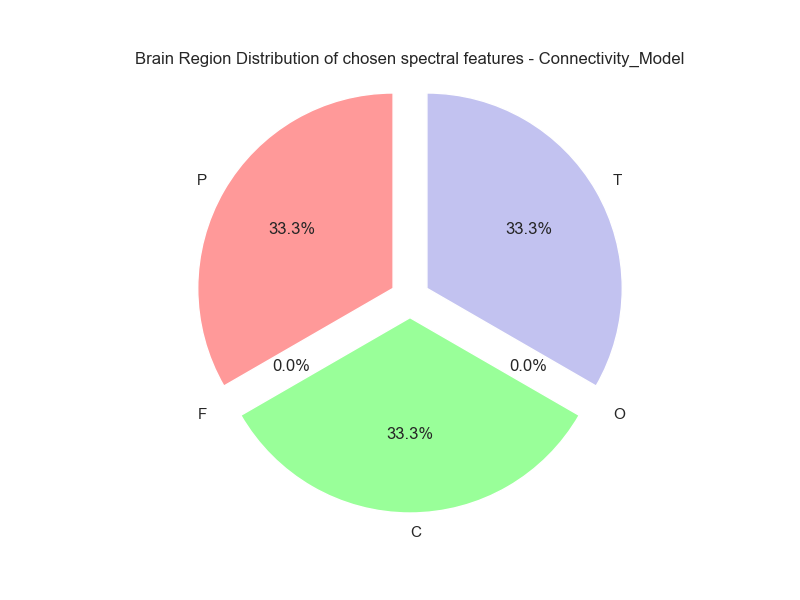

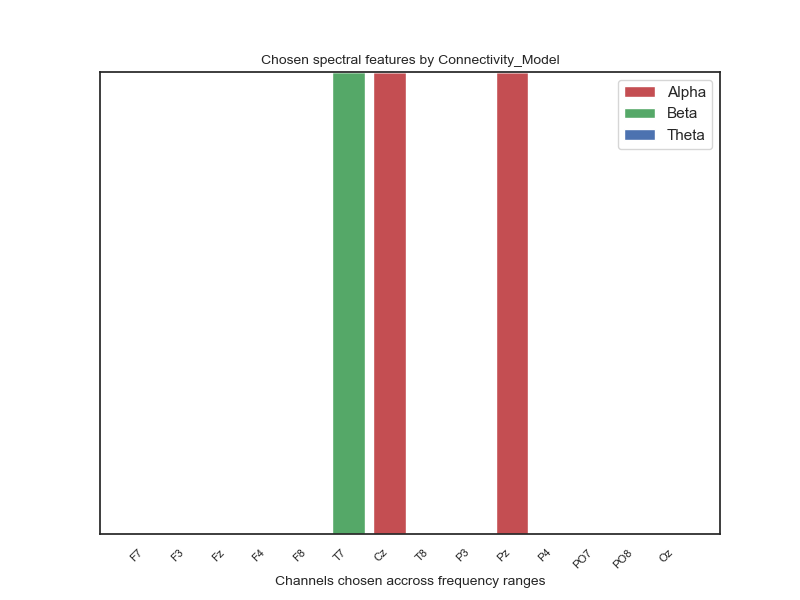

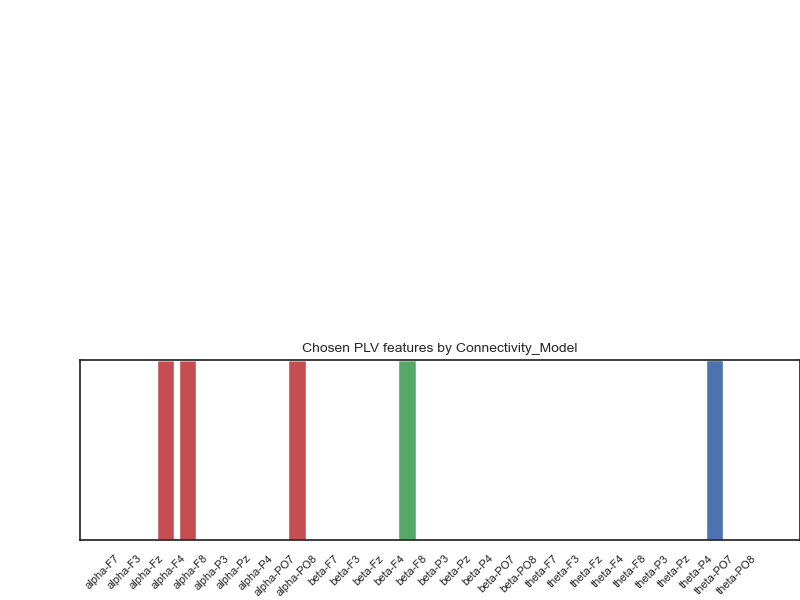

In [67]:
# plot features selected by the model

indexes = np.where(selected_feature_indices)[0]
plv_names = ['alpha-F7','alpha-F3','alpha-Fz','alpha-F4','alpha-F8',
             'alpha-P3','alpha-Pz','alpha-P4','alpha-PO7','alpha-PO8',
             'beta-F7','beta-F3','beta-Fz','beta-F4','beta-F8',
             'beta-P3','beta-Pz','beta-P4','beta-PO7','beta-PO8', 
             'theta-F7','theta-F3','theta-Fz','theta-F4','theta-F8',
             'theta-P3','theta-Pz','theta-P4','theta-PO7','theta-PO8'] 
node_names_orig = ['F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'Cz', 'T8', 'P3', 'Pz', 'P4', 'PO7', 'PO8', 'Oz']
combinations_total = plv_names + node_names_orig*3

alpha_plv, beta_plv, theta_plv = [], [], []
alpha_spec, beta_spec, theta_spec = [], [], []
for i in indexes:
    if i < 10:
        alpha_plv.append(combinations_total[i])
    elif i >= 10 and i < 20:
        beta_plv.append(combinations_total[i])
    elif i >= 20 and i < 30:
        theta_plv.append(combinations_total[i])
    elif i >= 30 and i < 44:
        alpha_spec.append(combinations_total[i])
    elif i >= 44 and i < 58:
        beta_spec.append(combinations_total[i])
    elif i >= 58 and i < 72:
        theta_spec.append(combinations_total[i])
        
# print(f'Number of chosen PLV features per frequency band: , \nAlpha: {len(alpha_plv)}  \nBeta: {len(beta_plv)} \nTheta: {len(theta_plv)}')
# print(' ')
# print(f'Number of chosen spectral features per frequency band: , \nAlpha: {len(alpha_spec)} \nBeta: {len(beta_spec)} \nTheta: {len(theta_spec)}')
    
frontal_count, parietal_count = 0, 0
channel_counts = {}
frequency_bands = [alpha_spec, beta_spec, theta_spec]
for frequency_band in frequency_bands:
    for channel in frequency_band:
        if channel in channel_counts:
            channel_counts[channel] += 1
        else:
            channel_counts[channel] = 1
    
cirkel_diagram(channel_counts, model='Connectivity_Model')
barplot_features(channel_counts, frequency_bands, node_names_orig, model='Connectivity_Model')

modelPLV_chosen_frequency_bands = [alpha_spec, beta_spec, theta_spec]

frontal_count, parietal_count = 0, 0
channel_counts = {}
frequency_bands = [alpha_plv, beta_plv, theta_plv]
for frequency_band in frequency_bands:
    for channel in frequency_band:
        if channel in channel_counts:
            channel_counts[channel] += 1
        else:
            channel_counts[channel] = 1
    
barplot_PLVfeatures(channel_counts, frequency_bands, plv_names, model='Connectivity_Model')

modelPLV_chosen_plv = [alpha_plv, beta_plv, theta_plv]


# Final plots

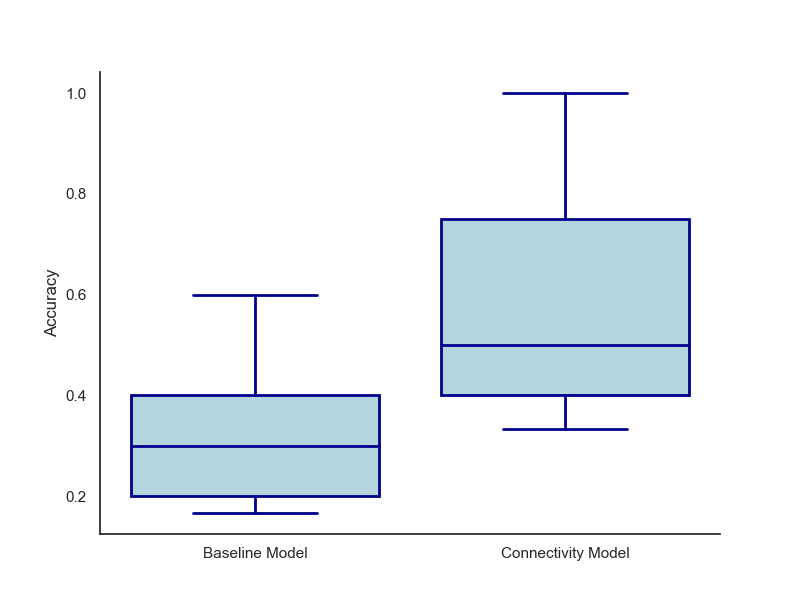

In [69]:
# Boxplot accuracy-scores per model.

data = [baseline_model_acc, model_PLV_acc]
sns.set(style="white")
palette = ["lightblue"]

plt.figure(figsize=(8, 6))
sns.boxplot(data=data, palette=palette, linewidth=2, boxprops={"edgecolor": "darkblue"}, medianprops={"color": "darkblue"}, whiskerprops={"color": "darkblue"}, capprops={"color": "darkblue"})
plt.xticks(ticks=range(len(['Baseline Model', 'Connectivity Model'])),labels=['Baseline Model', 'Connectivity Model'])
plt.ylabel("Accuracy")

sns.despine()
plt.show()
output_file = '/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/boxplot_accuracy.png'
# output_file = '/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/boxplot_accuracy.png'
plt.savefig(output_file, bbox_inches='tight')
plt.clf()

In [68]:
# Selected spectral features and PLV features per model.

chosen_FREQUENCYBANDs = chosen_frequency_bands, modelPLV_chosen_frequency_bands
models = ['Baseline', 'Model PLV']
for name, selected in zip(models, chosen_FREQUENCYBANDs):
    print(f'Selected spectral features of model {name}: {selected}')

name = 'Model PLV'
print(f'Selected PLV features of model {name}: {chosen_PLVs}') 

Selected spectral features of model Baseline: [['F4', 'Cz', 'PO8'], ['T7', 'T8', 'PO8'], ['F3', 'T8']]
Selected spectral features of model Model PLV: [['Cz', 'Pz'], ['T7'], []]
Selected PLV features of model Model PLV: [['Fz', 'F4', 'PO7'], ['F4'], ['P4']]


In [52]:
# Print model with highest accuracy among folds

acc_scorers = baseline_model_acc, model_PLV_acc
chosen_param = baseline_model_param, model_PLV_param

new_list = []
for i in acc_scorers:
    idx = np.argmax(i)
    new_list.append(i[idx])
idx1 = np.argmax(new_list)

if idx1 == 0:
    model = 'Baseline' 
elif idx1 == 1:
    model = 'Model PLV'
print(f'Best performing model based on highest accuracy among folds {model} \n with a max accuracy score of {new_list[idx1]}. \n with a mean accuracy score of {np.mean(acc_scorers[idx1])}. \n its best performing set of hyperparameters: {chosen_param[idx1]}.')

Best performing model based on highest accuracy among folds Model PLV 
 with a max accuracy score of 1.0. 
 with a mean accuracy score of 0.5733333333333334. 
 its best performing set of hyperparameters: {'C': 0.95, 'gamma': 10, 'kernel': 'rbf'}.


In [53]:
# Print best performing model based on highest mean accuracy over folds.

mean_acc_scorers = np.mean(acc_scorers, axis=1)
idx = np.argmax(mean_acc_scorers)
idx1 = np.argmax(acc_scorers[idx])
if idx == 0:
    model = 'Raw'
elif idx == 1:
    model = 'Baseline'
elif idx >= 2:
    model = idx-1
print(f'Best performing model based on highest mean accuracy is model {model} \n with a max accuracy score of {acc_scorers[idx][idx1]}. \n with a mean accuracy score of {np.mean(mean_acc_scorers[idx])}. \n its best performing set of hyperparameters: {chosen_param[idx]}.')

Best performing model based on highest mean accuracy is model Baseline 
 with a max accuracy score of 1.0. 
 with a mean accuracy score of 0.5733333333333334. 
 its best performing set of hyperparameters: {'C': 0.95, 'gamma': 10, 'kernel': 'rbf'}.


In [61]:
# load NASA-TLX scores
labels = '/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/raw/Table_logsandqrs.csv'
Desktop_labels = pd.read_csv(labels, sep=',')['NASA-TLX DESKTOP'].drop(44)
VR_labels = pd.read_csv(labels, sep=',')['NASA-TLX VR'].drop(44)
print(f'Max NASA-TLX scores: \nDesktop: {round(max(Desktop_labels),1)}, VR: {round(max(VR_labels),1)}')
print(f'Median NASA-TLX scores: \nDesktop: {round(np.median(Desktop_labels),1)}, VR: {round(np.median(VR_labels),1)}')

Max NASA-TLX scores: 
Desktop: 79.3, VR: 90.5
Median NASA-TLX scores: 
Desktop: 41.7, VR: 46.2


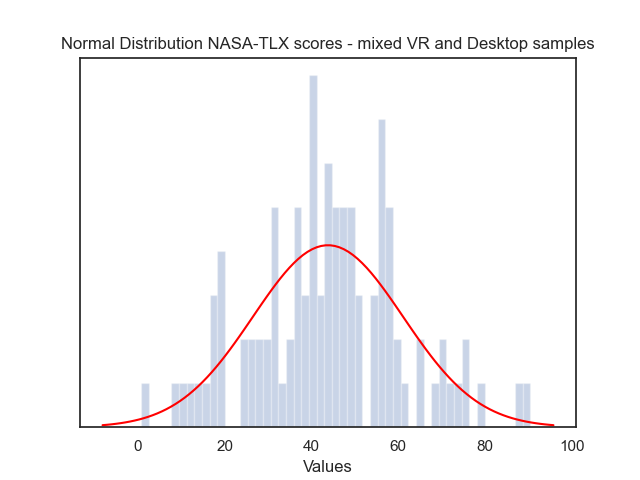

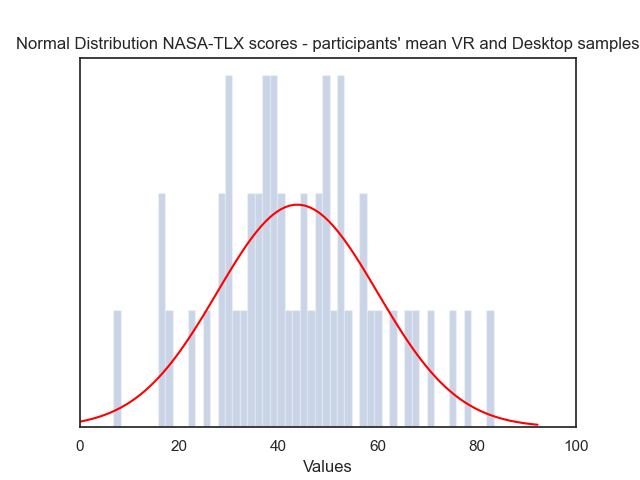

In [55]:
# normal distribution NASA-TLX scores, mixed VR and Desktop

mixed_values = pd.concat([Desktop_labels, VR_labels])
mean = np.mean(mixed_values)
std = np.std(mixed_values)

x = np.linspace(mean - 3*std, mean + 3*std, 100)
y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-(x - mean)**2 / (2 * std**2))

fig, ax = plt.subplots()

ax.plot(x, y, color='red')
ax.hist(mixed_values, bins=51, density=True, alpha=0.3)
ax.set_xlabel('Values')
ax.set_yticklabels([])
ax.set_title('Normal Distribution NASA-TLX scores - mixed VR and Desktop samples')
plt.show()
output_file = f'/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/normaldistribution_mixedsamples.png'
# output_file = f'/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/confusion_matrices/normaldistribution_mixedsamples.png'
plt.savefig(output_file, bbox_inches='tight')
plt.close()

# normal distribution of mean NASA-TLX scores participants

mean_participants = np.mean([Desktop_labels, VR_labels], axis=0)
mean = np.mean(mean_participants)
std = np.std(mean_participants)

x = np.linspace(mean - 3*std, mean + 3*std, 100)
y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-(x - mean)**2 / (2 * std**2))

fig, ax = plt.subplots()

ax.plot(x, y, color='red')
ax.hist(mean_participants, bins=51, density=True, alpha=0.3)
ax.set_xlabel('Values')
ax.set_xlim(0, 100)
ax.set_yticklabels([])
ax.set_title('Normal Distribution NASA-TLX scores - participants\' mean VR and Desktop samples')
plt.show()
output_file = f'/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/normaldistribution_meansamples.png'
# output_file = f'/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/confusion_matrices/normaldistribution_meansamples.png'
plt.savefig(output_file, bbox_inches='tight')
plt.close()


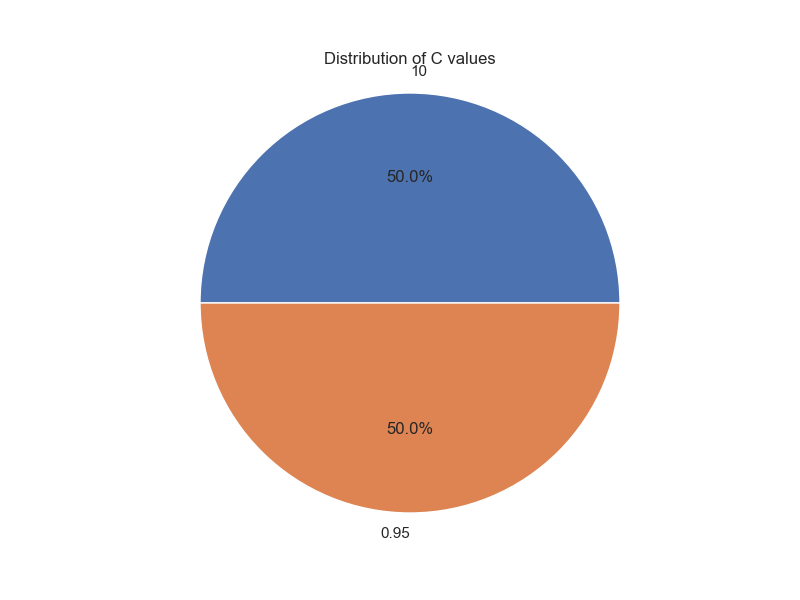

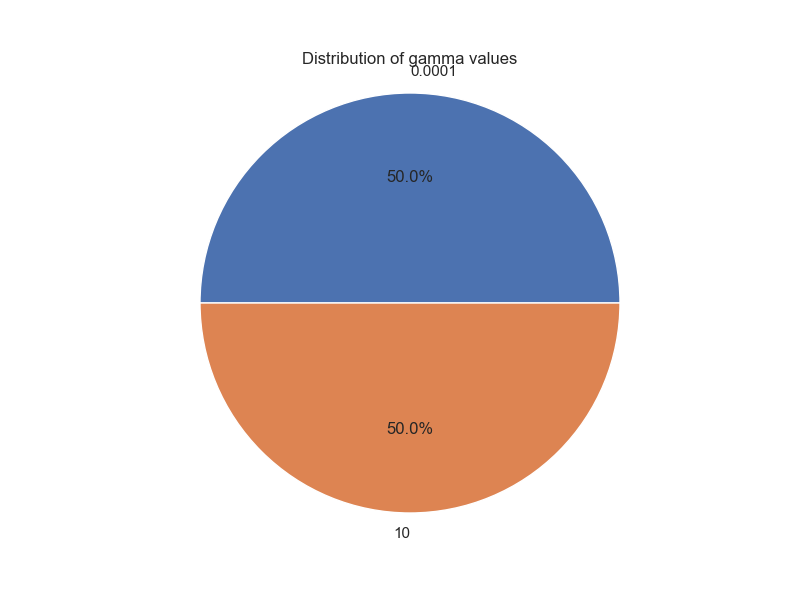

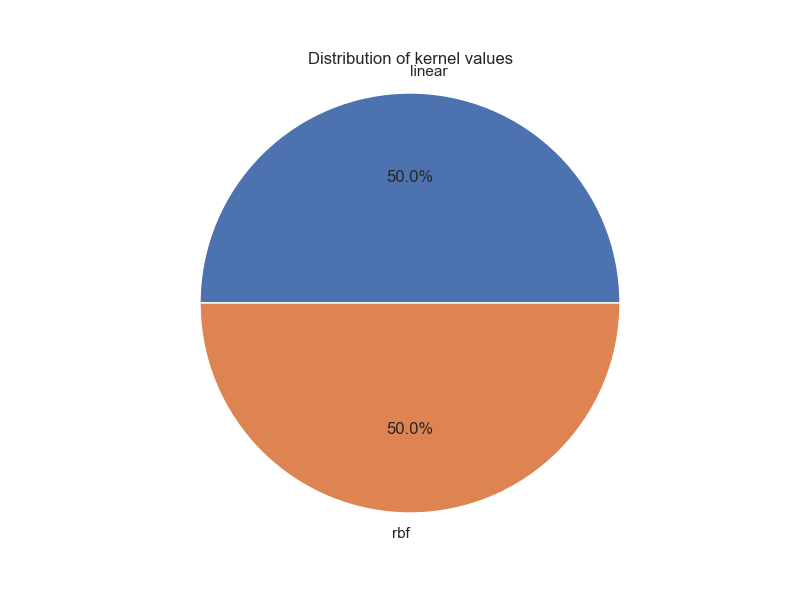

In [56]:
# Plot distribution of selected SVM-hyperparameters.

from collections import Counter
import matplotlib.pyplot as plt

chosen_param = baseline_model_param, model_PLV_param

c_counts = Counter(param['C'] for param in chosen_param)
gamma_counts = Counter(param['gamma'] for param in chosen_param)
kernel_counts = Counter(param['kernel'] for param in chosen_param)

def plot_hyperparameter_distribution(counts, title, model):
    labels, values = zip(*counts.items())
    plt.pie(values, labels=labels, autopct='%1.1f%%')
    plt.title(title)
    plt.axis('equal')
    plt.show()
    output_file = f'/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/selected_hyperparameters_SVM/hyperparameters_{model}.png'
    # output_file = f'/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/selected_hyperparameters_SVM/hyperparameters_{model}.png'
    plt.savefig(output_file, bbox_inches='tight')
    plt.clf()

plot_hyperparameter_distribution(c_counts, 'Distribution of C values', model='C')
plot_hyperparameter_distribution(gamma_counts, 'Distribution of gamma values', model='gamma')
plot_hyperparameter_distribution(kernel_counts, 'Distribution of kernel values', model='kernel')

In [57]:
# Custom plot functions for selected features over all models: spectral features barplot and PLV features barplot.

def custom_spectralfeatures_barplot(channel_counts, frequency_bands, all_channels, model):

    colors = ['r', 'g', 'b']
    x = np.arange(len(all_channels))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    bottom = np.zeros(len(all_channels))

    for i, freq in zip(range(len(frequency_bands)), ['Alpha', 'Beta', 'Theta']):
        for frequency in frequency_bands:
            values = [channel_counts[channel] if channel in frequency[i] else 0 for channel in all_channels]
            ax.bar(x, values, bottom=bottom, color=colors[i])
            bottom += values
    
    ax.set_xlabel('Channels for each frequency band', fontsize=10)
    ax.set_title(f'Chosen spectral features by {model}', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(all_channels, rotation=45, ha='right', fontsize=8)
    ax.yaxis.set_ticks([])
    legend_labels = ['Alpha', 'Beta', 'Theta']
    legend_colors = ['r', 'b', 'g']
    legend_patches = [mpatches.Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)]
    ax.legend(handles=legend_patches)

    plt.show()
    output_file = f'/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/barplotspectrumfeatures_{model}.png'
    # output_file = f'/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/barplotspectrumfeatures_{model}.png'
    plt.savefig(output_file, bbox_inches='tight')
    plt.clf()
    
def custom_PLVfeatures_barplot(channel_counts, frequency_bands, all_channels, model):

    colors = ['r', 'g', 'b']
    x = np.arange(len(all_channels))

    fig, ax = plt.subplots(figsize=(8, 6))
    bottom = np.zeros(len(all_channels))
        
    for i, freq in zip(range(len(frequency_bands)), ['Alpha', 'Beta', 'Theta']):
        values = [channel_counts[channel] if channel in frequency_bands[i] else 0 for channel in all_channels]
        ax.bar(x, values, bottom=bottom, color=colors[i])
        bottom += values
    
    ax.set_position([0.1, 0.1, 0.9, 0.3]) 
    ax.set_xlabel('PLV feature per channel and the frequency ranges', fontsize=10)
    ax.set_title(f'Chosen PLV features by {model}', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(all_channels, rotation=45, ha='right', fontsize=8)
    ax.yaxis.set_ticks([])
    
    plt.show()
    output_file = f'/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/barplotPLVfeatures_{model}.png'
    # output_file = f'/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/barplotPLVfeatures_{model}.png'
    plt.savefig(output_file, bbox_inches='tight')
    plt.clf()


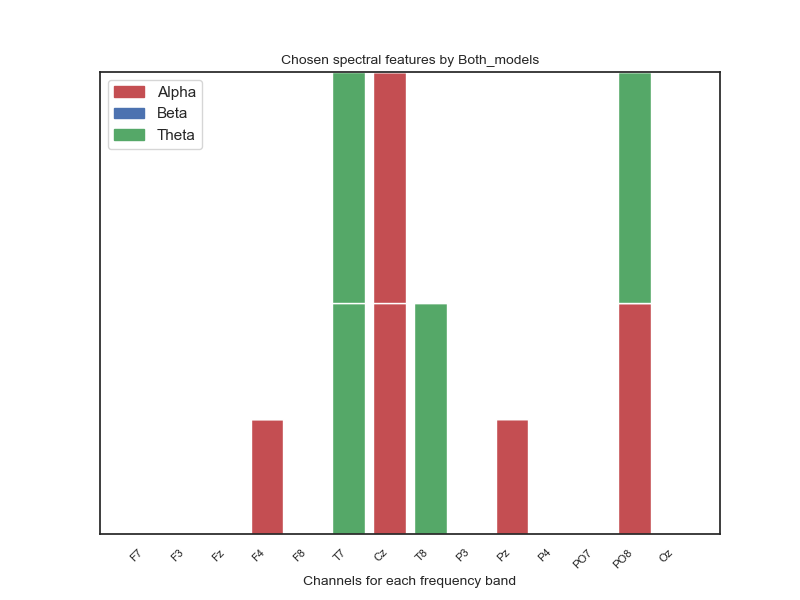

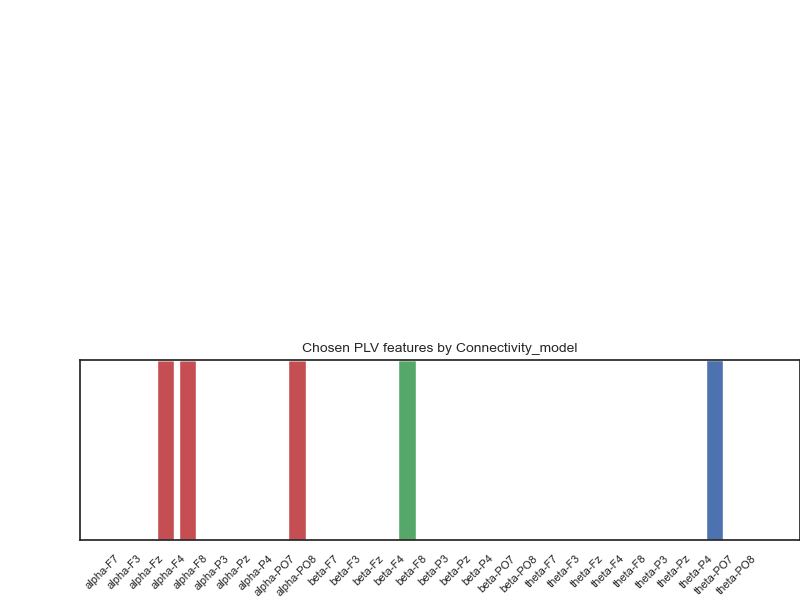

No such comm: 2dc8d1bd4a6e43afaa6f752309bdd089


In [58]:
# Plotting custom plots for selected features over all models.

plv_names = ['alpha-F7','alpha-F3','alpha-Fz','alpha-F4','alpha-F8',
             'alpha-P3','alpha-Pz','alpha-P4','alpha-PO7','alpha-PO8',
             'beta-F7','beta-F3','beta-Fz','beta-F4','beta-F8',
             'beta-P3','beta-Pz','beta-P4','beta-PO7','beta-PO8', 
             'theta-F7','theta-F3','theta-Fz','theta-F4','theta-F8',
             'theta-P3','theta-Pz','theta-P4','theta-PO7','theta-PO8'] 
node_names_orig = ['F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'Cz', 'T8', 'P3', 'Pz', 'P4', 'PO7', 'PO8', 'Oz']
    
channel_counts = {}
chosen_FREQUENCYBANDs = chosen_frequency_bands, modelPLV_chosen_frequency_bands
frequency_bands = chosen_FREQUENCYBANDs
for model in frequency_bands:
    for frequency_band in model:
        for channel in frequency_band:
            if channel in channel_counts:
                channel_counts[channel] += 1
            else:
                channel_counts[channel] = 1
            
custom_spectralfeatures_barplot(channel_counts, frequency_bands, node_names_orig, model='Both_models')

channel_counts = {}
chosen_PLVs = modelPLV_chosen_plv
frequency_bands = chosen_PLVs
for frequency_band in frequency_bands:
    for channel in frequency_band:
        if channel in channel_counts:
            channel_counts[channel] += 1
        else:
            channel_counts[channel] = 1

custom_PLVfeatures_barplot(channel_counts, frequency_bands, plv_names, model='Connectivity_model')


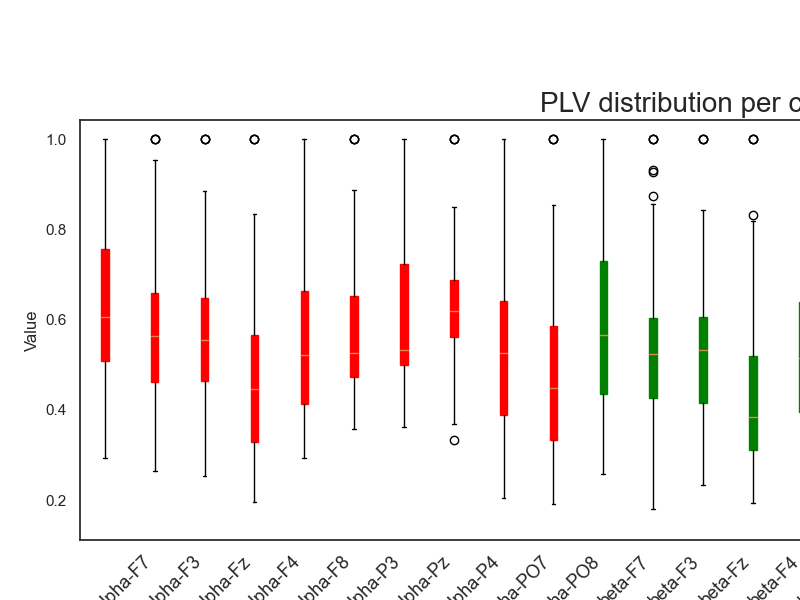

In [59]:
# Boxplot connectivity values among participants.

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['red', 'green', 'blue']

for i in range(len(concatenated_X[0])-42):
    color_index = i // 10 # Grouping every 10 variables
    color = colors[color_index]
    
    variable_data = [array[i] for array in concatenated_X]
    box = ax.boxplot(variable_data, positions=[i], boxprops={'color': color}, patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor(color)
        
ax.set_position([0.1, 0.1, 1.9, 0.7])
ax.set_xticks(range(1, len(concatenated_X[0])-41))
plv_names = ['alpha-F7','alpha-F3','alpha-Fz','alpha-F4','alpha-F8',
             'alpha-P3','alpha-Pz','alpha-P4','alpha-PO7','alpha-PO8',
             'beta-F7','beta-F3','beta-Fz','beta-F4','beta-F8',
             'beta-P3','beta-Pz','beta-P4','beta-PO7','beta-PO8', 
             'theta-F7','theta-F3','theta-Fz','theta-F4','theta-F8',
             'theta-P3','theta-Pz','theta-P4','theta-PO7','theta-PO8'] 
ax.set_xticklabels(plv_names, rotation=45, ha='right', fontsize=13)
ax.set_title('PLV distribution per channel and frequency band', fontsize=20)
ax.set_ylabel('Value')
plt.show()
output_file = '/Users/basverkennis/Desktop/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/boxplot_connectivity.png'
# output_file = '/Flight-Sim-Cognitive-Workload-EEG-Prediction/results/boxplot_connectivity.png'
plt.savefig(output_file, bbox_inches='tight')
plt.close()